# Smart Cargo E-Bike, Part 4 — 3-D Multibody Dynamics & Co-Simulation (MuJoCo)

**Reading time ~30 min · runtime ~2 min on CPU (MuJoCo steps in real-time; one
~50 s Jaxonomy planar run for the comparison).**

The [Part 1](ebike_smart_cargo_tutorial.ipynb) vehicle is a **bird's-eye 3-DOF
planar** model: longitudinal, lateral, and yaw motion of a rigid body on a flat
plane. It is perfect for energy, range, and control-loop design — but it has, by
construction, **no vertical motion, no pitch, no suspension, and no ground
contact**. It cannot tell you whether a heavily-loaded cargo bike squats,
pitches under braking, or bottoms out its suspension over a kerb.

For those questions you need **3-D multibody dynamics**. Here we build the
companion the planar model is blind to: a MuJoCo cargo e-bike with real
tyre-ground contact and suspension, driven by the *same* assist-torque law, and
we run it **in co-simulation** — Jaxonomy-style controller, MuJoCo plant.

> **Prerequisites.** Part 1. Requires `mujoco` (`pip install mujoco`). We reuse
> the co-sim from `ebike_mujoco_cosim.py`.

## 1. What multibody dynamics *is* (and how it differs from 0-D/1-D)

A multibody model tracks a set of rigid bodies linked by **joints**. Its state
is a vector of **generalized coordinates** $\mathbf q$ (joint angles/positions)
and velocities $\dot{\mathbf q}$, and it obeys the equations of motion
$$ \mathbf M(\mathbf q)\,\ddot{\mathbf q} + \mathbf c(\mathbf q,\dot{\mathbf q}) = \boldsymbol\tau + \mathbf J^{\!\top}\boldsymbol\lambda, \tag{1}$$
where $\mathbf M$ is the (configuration-dependent) mass matrix, $\mathbf c$
gathers Coriolis/centrifugal/gravity terms, $\boldsymbol\tau$ are applied
joint torques, and $\mathbf J^{\!\top}\boldsymbol\lambda$ are constraint forces
(contacts, joint limits). Dimensional sanity: each row of (1) is a
Newton–Euler balance — $[\mathbf M \ddot q]=$ N·m for a rotational DOF.

**Contact & friction** are the hard part. MuJoCo (Todorov 2012) uses a
*soft, convex* contact model: instead of hard complementarity ("either no
penetration or no force"), it solves a well-posed convex optimization each step
for contact impulses, which makes contact-rich simulation fast and
differentiable-friendly at the cost of a little compliance.

**How this differs from the acausal 0-D/1-D world of Parts 1–3.** Those models
are *lumped*: a scalar per state, algebraic/ODE/DAE couplings, no geometry.
Multibody adds **kinematic geometry** — where bodies are in 3-D space, how they
rotate, how they touch the ground. That geometry is exactly what produces pitch,
weight transfer, and suspension response. It is complementary, not competing:
the lumped model owns the powertrain/energy; the multibody model owns the
chassis motion.

## 2. Setup and the co-simulation contract

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage

sys.path.append(os.path.abspath("."))
import ebike_mujoco_cosim as mj
from ebike_mujoco_cosim import MEDIA, run, wheel_drive_torque

print("MuJoCo scene:", os.path.basename(mj.XML))

MuJoCo scene: ebike_mujoco.xml


**The co-simulation loop.** Each control tick, the *controller* reads sensors
(forward speed) and computes a rear-wheel drive torque from the same speed-faded
assist law as Part 1 (human pedal + motor assist, cut at the 25 km/h legal
limit); the *plant* (MuJoCo) integrates the full 3-D dynamics with contact and
suspension and returns the next state. This is **controller-in-the-loop
co-simulation**: two solvers, a clean sensor/actuator interface, stepped in
lockstep. (Swap the plant for hardware and the same interface becomes
hardware-in-the-loop.)

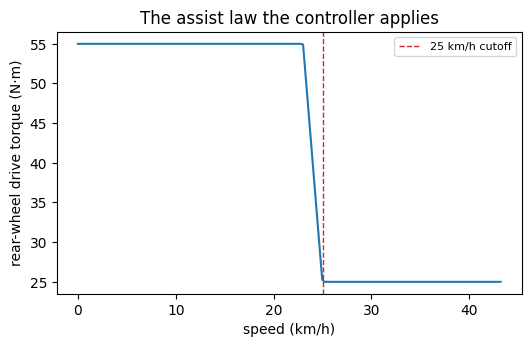

In [2]:
v = np.linspace(0, 12, 200)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(v * 3.6, [wheel_drive_torque(vi) for vi in v], color="tab:blue")
ax.axvline(25, color="tab:red", ls="--", lw=1, label="25 km/h cutoff")
ax.set(xlabel="speed (km/h)", ylabel="rear-wheel drive torque (N·m)",
       title="The assist law the controller applies"); ax.legend(fontsize=8)
plt.show()

*Figure 1: the wheel-torque law — constant rider contribution plus a
speed-faded motor assist that switches off at the legal 25 km/h, matching the
Part-1 policy.*

## 3. The ride — what the 3-D model resolves that the planar one cannot

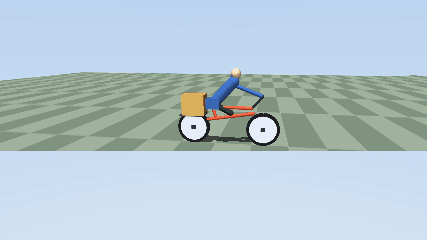

In [3]:
IPyImage(filename=os.path.join(MEDIA, "ebike_mujoco_cosim.gif"))

*Animation: the cargo bike accelerates from rest, pitches nose-up as assist
kicks in, compresses its suspension over the speed bump, and coasts once past
the cutoff. Roll and yaw are suppressed by construction (a sagittal-plane base:
longitudinal slide + vertical heave + pitch hinge) so the run stays upright
without solving bicycle self-balance — the point here is the **sagittal**
physics, not lateral stability.*

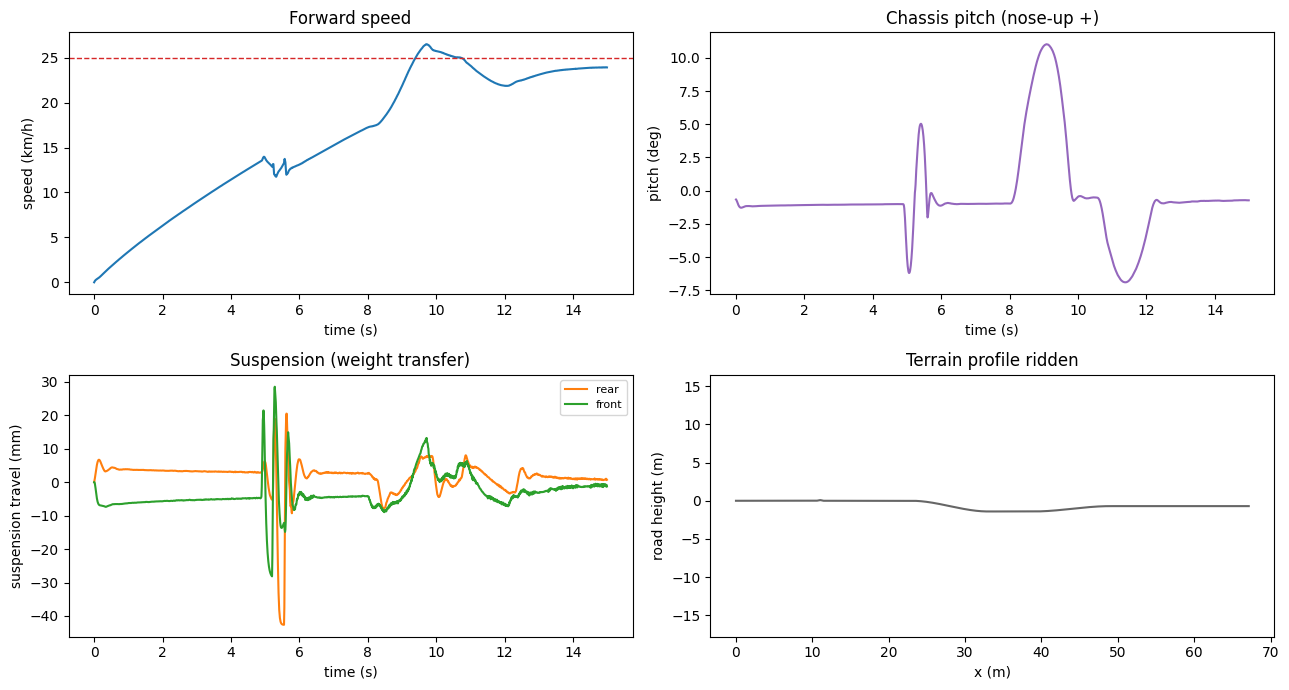

In [4]:
tr = run(t_end=15.0)                     # a live co-sim run (~0.2 s)
t = tr["t"]
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
ax[0, 0].plot(t, tr["speed_mps"] * 3.6, color="tab:blue"); ax[0, 0].axhline(25, color="tab:red", ls="--", lw=1)
ax[0, 0].set(xlabel="time (s)", ylabel="speed (km/h)", title="Forward speed")
ax[0, 1].plot(t, np.degrees(tr["pitch_rad"]), color="tab:purple")
ax[0, 1].set(xlabel="time (s)", ylabel="pitch (deg)", title="Chassis pitch (nose-up +)")
ax[1, 0].plot(t, tr["susp_travel_m"] * 1000, color="tab:orange", label="rear")
ax[1, 0].plot(t, tr["front_travel_m"] * 1000, color="tab:green", label="front")
ax[1, 0].set(xlabel="time (s)", ylabel="suspension travel (mm)", title="Suspension (weight transfer)"); ax[1, 0].legend(fontsize=8)
ax[1, 1].plot(tr["x_m"], tr["road_h_m"], color="0.4")
ax[1, 1].set(xlabel="x (m)", ylabel="road height (m)", title="Terrain profile ridden"); ax[1, 1].axis("equal")
fig.tight_layout(); plt.show()

*Figure 2: a single co-sim run. Every panel except speed is **structurally
absent from the planar model**: chassis pitch (±~10°), front/rear suspension
travel (the rear carries the cargo bias and compresses more; both spike over the
bump — that is dynamic weight transfer), and the vertical terrain the bike
actually rode.*

## 4. Phase portraits & a 3-D view

Multibody state lives in phase space. Two views the planar model has no
coordinates for: the **pitch phase portrait** (angle vs rate — a stable focus
spiralling to the loaded equilibrium) and the **suspension force–deflection
loop** (hysteresis = energy dissipated per bump cycle by the damper).

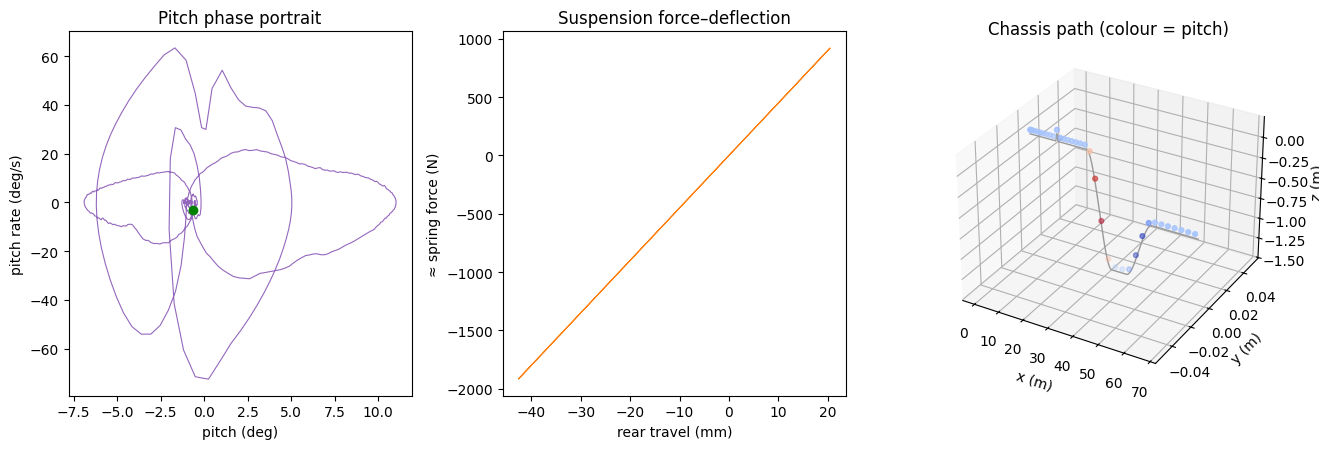

In [5]:
pitch = np.degrees(tr["pitch_rad"]); pitch_rate = np.gradient(pitch, t)
rear_mm = tr["susp_travel_m"] * 1000
K_SUSP = 45000.0  # N/m, illustrative spring rate for the force axis
fig = plt.figure(figsize=(13, 4.6))
axa = fig.add_subplot(1, 3, 1)
axa.plot(pitch, pitch_rate, color="tab:purple", lw=0.8); axa.plot(pitch[0], pitch_rate[0], "go")
axa.set(xlabel="pitch (deg)", ylabel="pitch rate (deg/s)", title="Pitch phase portrait")
axb = fig.add_subplot(1, 3, 2)
axb.plot(rear_mm, K_SUSP * tr["susp_travel_m"], color="tab:orange", lw=0.8)
axb.set(xlabel="rear travel (mm)", ylabel="≈ spring force (N)", title="Suspension force–deflection")
axc = fig.add_subplot(1, 3, 3, projection="3d")
axc.plot(tr["x_m"], np.zeros_like(t), tr["road_h_m"], color="0.6", lw=1, label="track")
axc.scatter(tr["x_m"][::40], np.zeros_like(t)[::40], tr["road_h_m"][::40] + 0.05,
            c=pitch[::40], cmap="coolwarm", s=12)
axc.set(xlabel="x (m)", ylabel="y (m)", zlabel="z (m)", title="Chassis path (colour = pitch)")
fig.tight_layout(); plt.show()

*Figure 3: (left) pitch spirals into its loaded equilibrium — a damped
second-order chassis mode; (middle) the force–deflection loop's enclosed area is
the energy the rear damper burns over the bump; (right) the ground track in 3-D,
coloured by pitch. None of these observables exist in a planar model.*

## 5. A parametric study only 3-D can do: weight transfer vs cargo

Load a cargo bike and the chassis *sits down* on its suspension and pitches
differently — first-order design information (suspension travel budget, ground
clearance, handling) that a lumped model simply does not carry. We sweep the
rear payload and read the 3-D response.

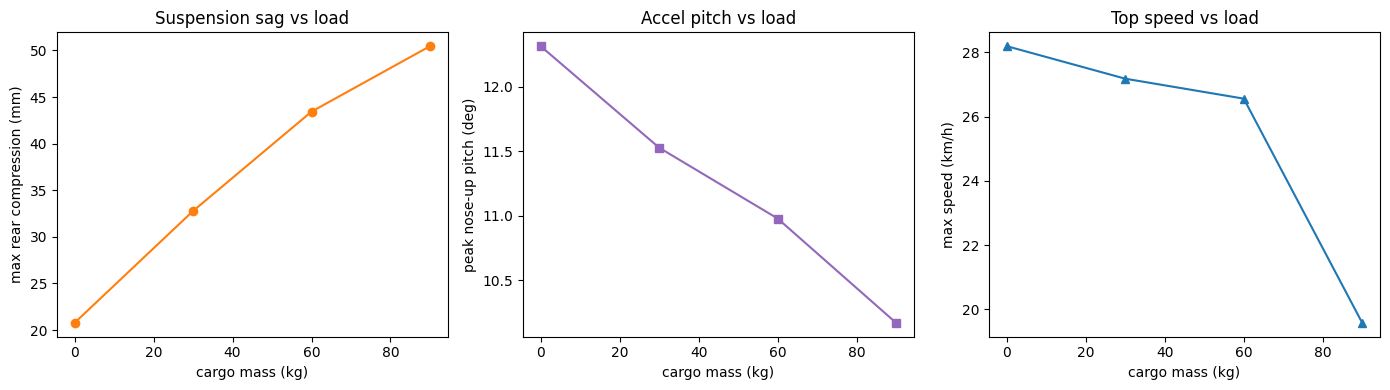

cargo sweep (kg -> rear_compression mm, peak_pitch deg, vmax km/h):
      0    20.8    12.3    28.2
     30    32.8    11.5    27.2
     60    43.4    11.0    26.6
     90    50.5    10.2    19.6


In [6]:
cargos = [0.0, 30.0, 60.0, 90.0]
rows = []
for m in cargos:
    r = run(t_end=10.0, cargo_mass=m)
    rows.append((m, r["susp_travel_m"].min() * 1000, np.degrees(r["pitch_rad"]).max(),
                 r["speed_mps"].max() * 3.6))
rows = np.array(rows)
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(rows[:, 0], -rows[:, 1], "o-", color="tab:orange"); ax[0].set(xlabel="cargo mass (kg)", ylabel="max rear compression (mm)", title="Suspension sag vs load")
ax[1].plot(rows[:, 0], rows[:, 2], "s-", color="tab:purple"); ax[1].set(xlabel="cargo mass (kg)", ylabel="peak nose-up pitch (deg)", title="Accel pitch vs load")
ax[2].plot(rows[:, 0], rows[:, 3], "^-", color="tab:blue"); ax[2].set(xlabel="cargo mass (kg)", ylabel="max speed (km/h)", title="Top speed vs load")
fig.tight_layout(); plt.show()
print("cargo sweep (kg -> rear_compression mm, peak_pitch deg, vmax km/h):")
for m, s, p, vmx in rows:
    print(f"  {m:5.0f}  {-s:6.1f}  {p:6.1f}  {vmx:6.1f}")

*Figure 4: heavier payload → more rear suspension compression (static + dynamic
weight transfer), less nose-up pitch under acceleration (the rear-biased load
resists it), and lower top speed (more mass to push against drag+grade). This is
the class of question — ride height, travel budget, handling balance — that
justifies a multibody model.*

## 6. Consistency with the planar model

The 3-D and planar models should agree *in the plane* they share (longitudinal
speed) and differ only out of it. We run the Part-1 planar model on flat ground
with the same assist policy and overlay.

jaxonomy/acausal/diagram_processing.py:1633: UserWarning: Conflicting weak ICs for np14_rotational_spd_0=0.0 and aliasee ic=0.757575, ignoring the latter.
  warnings.warn(msg, UserWarning)
jaxonomy/acausal/diagram_processing.py:1633: UserWarning: Conflicting weak ICs for np0_electrical_volt_0=48.0 and aliasee ic=50.699999999999996, ignoring the latter.
  warnings.warn(msg, UserWarning)


jaxonomy/acausal/index_reduction/index_reduction.py:1131: UserWarning: The number of initial conditions provided are correct. However, the provided set does not lead to a structurally feasible system. Provided initial conditions were for variables: dict_keys([battery_mod0_cell0_SOC(t), battery_mod0_cell0_SOH(t), battery_mod0_cell0_T_core(t), battery_mod0_cell0_V_RC1(t), battery_mod0_cell0_V_RC2(t), battery_mod0_cell0_dSOC(t), battery_mod0_cell0_dSOH(t), battery_mod0_cell0_dT_core(t), motor_T_rotor(t), motor_T_stator(t), motor_id_sym(t), motor_iq_sym(t), np11_rotational_spd_0(t), np17_rotational_spd_n1(t), np18_rotational_spd_0(t), np18_rotational_spd_n1(t), np3_thermal_temp_0(t), np6_thermal_temp_0(t), vehicle_psi(t), vehicle_r(t), vehicle_u(t), vehicle_v_lat(t), vehicle_x(t), vehicle_y(t)]). A different combination of initial values for any 24 variables from the following 92 variables: [battery_mod0_cell0_SOH(t), battery_mod0_cell0_dV_RC1(t), battery_mod0_cell0_V_RC2(t), battery_mod0_

jaxonomy/acausal/index_reduction/index_reduction.py:1037: UserWarning: Initial-condition resolution overrode declared (non-fixed) initial conditions: np0_electrical_volt_0(t): declared ic=48, initialized to 53.0944. Non-fixed ICs are only starting guesses for the consistent-initialization solve; the strong (fixed) ICs and model equations determined different values. To enforce a declared value, mark it fixed (ic_fixed=True on the symbol, or the component's *_ic_fixed=True argument), or fix a related port variable to a value consistent with it.
  warn_declared_weak_ics_overridden(self.ics_weak, X_ic_mapping)


jaxonomy/acausal/acausal_compiler.py:401: UserWarning: Initial-condition resolution overrode declared (non-fixed) initial conditions: np0_electrical_volt_0(t): declared ic=48, initialized to 53.0944. Non-fixed ICs are only starting guesses for the consistent-initialization solve; the strong (fixed) ICs and model equations determined different values. To enforce a declared value, mark it fixed (ic_fixed=True on the symbol, or the component's *_ic_fixed=True argument), or fix a related port variable to a value consistent with it.
  warn_declared_weak_ics_overridden(sed.ics_weak, X_ic_mapping)


18:09:31.300 - [jaxonomy][INFO]: max_major_steps=2998 based on smallest discrete period=0.01


18:09:31.301 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2998, ode_solver_method=auto, rtol=0.0005, atol=5e-06, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), BDFSolver(system=Diagram(ebike_system, 19 nodes), rtol=0.0005, atol=5e-06, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


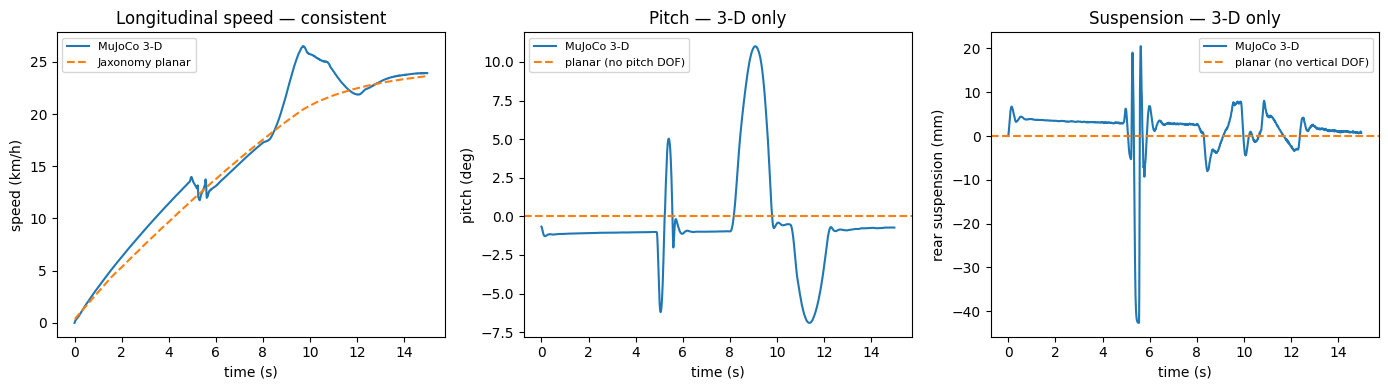

In [7]:
import jaxonomy
from jaxonomy.simulation import SimulatorOptions
from ebike_hybrid_simulation import make_ebike_diagram, EbikeConfig
_cfg = EbikeConfig(grade_hold=0.0, tf=15.0)
_diag = make_ebike_diagram(_cfg)
_opts = SimulatorOptions(enable_autodiff=False, rtol=5e-4, atol=5e-6, buffer_length=120000)
_res = jaxonomy.simulate(_diag, _diag.create_context(), (0.0, 15.0), options=_opts,
                         recorded_signals={p.name: p for p in _diag.output_ports if p.name == "speed"})
t_pl = np.asarray(_res.time); v_pl = np.asarray(_res.outputs["speed"]).squeeze() * 3.6

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(tr["t"], tr["speed_mps"] * 3.6, color="tab:blue", label="MuJoCo 3-D")
ax[0].plot(t_pl, v_pl, "--", color="tab:orange", label="Jaxonomy planar")
ax[0].set(xlabel="time (s)", ylabel="speed (km/h)", title="Longitudinal speed — consistent"); ax[0].legend(fontsize=8)
ax[1].plot(tr["t"], np.degrees(tr["pitch_rad"]), color="tab:blue", label="MuJoCo 3-D")
ax[1].axhline(0, color="tab:orange", ls="--", label="planar (no pitch DOF)")
ax[1].set(xlabel="time (s)", ylabel="pitch (deg)", title="Pitch — 3-D only"); ax[1].legend(fontsize=8)
ax[2].plot(tr["t"], tr["susp_travel_m"] * 1000, color="tab:blue", label="MuJoCo 3-D")
ax[2].axhline(0, color="tab:orange", ls="--", label="planar (no vertical DOF)")
ax[2].set(xlabel="time (s)", ylabel="rear suspension (mm)", title="Suspension — 3-D only"); ax[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

*Figure 5: the two models track in longitudinal speed (both accelerate under
assist and coast past cutoff), while pitch and suspension exist only in 3-D.
That agreement-in-plane is the validation; the divergence-out-of-plane is the
value.*

## 7. When to reach for multibody — and its limits

**Use multibody when the question is geometric/mechanical:** ride & handling,
suspension sizing, weight transfer and stability, durability load cases,
contact-rich manoeuvres (kerbs, potholes), and — with **MJX** (JAX-native
MuJoCo) — differentiable, GPU-batched rollouts for policy optimization and
sim-to-real RL.

**Stay lumped when the question is energetic/control:** range, efficiency,
thermal, controller tuning — Parts 1–3 answer those far more cheaply.

**Limitations.** (i) *Parameter identification* — inertias, contact stiffness,
and damping are hard to measure; garbage-in. (ii) *Contact fidelity* — MuJoCo's
soft-convex contact is fast but approximate; true stress/strain needs FEA.
(iii) *Rigid bodies* — frame flex, tyre carcass deformation are not captured
without flexible-body extensions. (iv) *Self-balancing* — a free bicycle is
famously hard; we sidestepped it by constraining roll, which is fine for
sagittal studies but not for handling/stability work.

**Alternatives.** Simscape Multibody, Drake, Bullet/PyBullet, Isaac Sim;
analytical bicycle models (Whipple/Carvallo) for stability; full FEA for
structural loads.

## 8. Failure modes

- **Contact instability** — too-stiff contacts or too-large a timestep make the
  wheels chatter or tunnel through the road; MuJoCo needs `mass and inertia >
  mjMINVAL` on every moving body (no massless intermediate links).
- **Heightfield hull mismatch** — the collision hull is compiled from the XML,
  so rescaling terrain at runtime lets wheels sink; fix the envelope in the MJCF.
- **Unphysical parameters** — a bogus contact stiffness or inertia gives
  plausible-looking but wrong dynamics; always sanity-check against a known case.
- **Reading too much into a constrained model** — we suppressed roll/yaw, so
  nothing here speaks to lateral stability; don't over-interpret.

## 9. Exercises

1. **(code)** Raise the speed-bump height in `road_height` and watch the
   suspension force–deflection loop grow. How does dissipated energy scale?
2. **(code)** Extend the cargo sweep to also record *braking* pitch (add a
   deceleration phase). Does the load shift forward as expected?
3. **(concept)** The bike model constrains roll. What would you need to add to
   study countersteering and self-stability, and why is that hard?
4. **(concept)** Sketch a **hardware-in-the-loop** version of this co-sim: which
   signals cross the boundary, and what real-time constraints appear?
5. **(open-ended)** Port the plant to **MJX** and use `jax.grad` through a
   batched rollout to tune a suspension parameter for minimum peak chassis
   acceleration over the bump.

## Key takeaways

- Multibody dynamics adds the **3-D kinematic geometry** (pitch, heave,
  contact, suspension) that lumped 0-D/1-D models structurally omit.
- **Co-simulation** cleanly splits controller (Jaxonomy) from plant (MuJoCo)
  over a sensor/actuator interface — the same interface generalizes to HIL.
- The two models **agree in-plane and diverge out-of-plane**: use that to
  validate the reduced model and to know what it cannot tell you.
- Reach for multibody on **geometric/mechanical** questions (ride, handling,
  loads); stay lumped for **energetic/control** ones. MJX makes the 3-D plant
  differentiable for optimization.

**Next:** [Part 5](ebike_part5_openfoam_cfd.ipynb) — CFD & conjugate heat
transfer with OpenFOAM.

## References
- R. Featherstone, *Rigid Body Dynamics Algorithms*, Springer 2008.
- E. Todorov, T. Erez, Y. Tassa, *MuJoCo: A physics engine for model-based control*, IROS 2012.
- MuJoCo MJX documentation (JAX-native MuJoCo).